In [1]:
# ═══════════════════════════════════════════════════════════════
# Cell 1 — Imports & Config
# ═══════════════════════════════════════════════════════════════
import gc
import json
import random
import psutil
import ast
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("data")
MODEL_ID  = "HuggingFaceTB/SmolVLM-500M-Instruct"
LOG_DIR   = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

BEST_CKPT = LOG_DIR / "dora_vision_resume_epoch9_20260430_175706"

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [2]:
# ═══════════════════════════════════════════════════════════════
# Cell 2 — Load Data
# ═══════════════════════════════════════════════════════════════
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(ast.literal_eval)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
total_nli = train_df["num_choices"].sum()
print(f"Expanded NLI train examples: {total_nli:,}")

Train: 3,109 | Val: 1,048 | Test: 1,008
Expanded NLI train examples: 9,666


In [3]:
# ═══════════════════════════════════════════════════════════════
# Cell 3 — Load Processor
# ═══════════════════════════════════════════════════════════════
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

processor.image_processor.do_image_splitting = False
processor.image_processor.size              = {"longest_edge": 512}
processor.image_processor.max_image_size    = {"longest_edge": 512}

yes_token = processor.tokenizer("Yes", add_special_tokens=False)["input_ids"][0]
no_token  = processor.tokenizer("No",  add_special_tokens=False)["input_ids"][0]
print(f"'Yes' token: {yes_token} | 'No' token: {no_token}")
print(f"do_image_splitting: {processor.image_processor.do_image_splitting}")

'Yes' token: 10539 | 'No' token: 5230
do_image_splitting: False


In [4]:
# ═══════════════════════════════════════════════════════════════
# Cell 4 — Prompt Builder & Scoring
# ═══════════════════════════════════════════════════════════════
def build_nli_prompt(row, choice_text, include_answer=False, max_context_chars=2000):
    text = ""
    if pd.notna(row.get("lecture", None)) and row["lecture"]:
        text += f"Background:\n{row['lecture'][:max_context_chars]}\n\n"
    if pd.notna(row.get("hint", None)) and row["hint"]:
        text += f"Passage:\n{row['hint'][:max_context_chars]}\n\n"
    text += f"Question: {row['question']}\n"
    text += f"Proposed answer: {choice_text}\n"
    text += "Is this the correct answer? Yes or No."
    prompt = f"<|im_start|>User:<image>{text}<end_of_utterance>\nAssistant:"
    if include_answer:
        prompt += " Yes" if include_answer == "yes" else " No"
    return prompt

def score_choices_nli(model, processor, image, row, choices, max_context_chars=2000):
    scores = []
    for choice in choices:
        prompt = build_nli_prompt(row, choice, max_context_chars=max_context_chars)
        inputs = processor(text=[prompt], images=[image],
                          return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits[:, -1, :]
        score = logits[0, yes_token].item() - logits[0, no_token].item()
        scores.append(score)
        del outputs, logits, inputs
        torch.cuda.empty_cache()
    return int(torch.tensor(scores).argmax().item())

def evaluate(model, val_df, data_dir, n_samples=500, seed=42):
    model.eval()
    subset  = val_df.sample(min(n_samples, len(val_df)), random_state=seed).reset_index(drop=True)
    correct = 0
    for idx in tqdm(range(len(subset)), desc="Val eval"):
        row   = subset.iloc[idx]
        image = Image.open(data_dir / row["image_path"]).convert("RGB")
        pred  = score_choices_nli(model, processor, image, row, row["choices"])
        if pred == int(row["answer"]):
            correct += 1
    acc = correct / len(subset)
    print(f"Val accuracy ({len(subset)} samples): {acc:.4f}")
    model.train()
    return acc

In [5]:
# ═══════════════════════════════════════════════════════════════
# Cell 5 — NLI Dataset
# ═══════════════════════════════════════════════════════════════
class NLIDataset(Dataset):
    def __init__(self, df, data_dir, max_context_chars=2000):
        self.data_dir          = data_dir
        self.max_context_chars = max_context_chars
        self.examples          = []

        for _, row in df.iterrows():
            img_path = data_dir / row["image_path"]
            for j, choice in enumerate(row["choices"]):
                is_correct = (j == int(row["answer"]))
                self.examples.append({
                    "image_path": img_path,
                    "prompt":     build_nli_prompt(
                                      row, choice,
                                      include_answer="yes" if is_correct else "no",
                                      max_context_chars=max_context_chars
                                  ),
                    "label":      1 if is_correct else 0,
                    "question":   row["question"],
                    "subject":    row["subject"],
                    "grade":      row["grade"],
                })

        print(f"NLIDataset: {len(self.examples):,} examples")
        labels = [ex["label"] for ex in self.examples]
        print(f"  Yes: {sum(labels):,} | No: {len(labels)-sum(labels):,}")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex  = self.examples[idx]
        img = Image.open(ex["image_path"]).convert("RGB")
        return {
            "image":    img,
            "text":     ex["prompt"],
            "label":    ex["label"],
            "question": ex["question"],
        }

train_nli_ds = NLIDataset(train_df, DATA_DIR)

NLIDataset: 9,666 examples
  Yes: 3,109 | No: 6,557


In [6]:
# ═══════════════════════════════════════════════════════════════
# Cell 6 — Collate Function
# ═══════════════════════════════════════════════════════════════
assistant_token_ids = processor.tokenizer(
    "Assistant:", add_special_tokens=False
)["input_ids"]
print(f"'Assistant:' token ids: {assistant_token_ids}")

def collate_fn(batch):
    images    = [b["image"]    for b in batch]
    texts     = [b["text"]     for b in batch]
    labels    = [b["label"]    for b in batch]
    questions = [b["question"] for b in batch]

    inputs = processor(
        text=texts, images=images,
        return_tensors="pt", padding=True,
    )

    loss_labels = inputs["input_ids"].clone()
    loss_labels[loss_labels == processor.tokenizer.pad_token_id] = -100

    for i in range(loss_labels.shape[0]):
        seq   = inputs["input_ids"][i].tolist()
        found = False
        for pos in range(len(seq) - len(assistant_token_ids)):
            if seq[pos:pos + len(assistant_token_ids)] == assistant_token_ids:
                loss_labels[i, :pos + len(assistant_token_ids)] = -100
                found = True
                break
        if not found:
            loss_labels[i, :] = -100

    inputs["labels"] = loss_labels
    return inputs, torch.tensor(labels), questions

# Verify
sample_batch = [train_nli_ds[i] for i in range(4)]
inputs_test, labels_test, _ = collate_fn(sample_batch)
for i in range(4):
    label_ids  = inputs_test["labels"][i]
    valid_ids  = label_ids[label_ids != -100]
    decoded    = processor.tokenizer.decode(valid_ids)
    print(f"Sample {i+1} | label={labels_test[i].item()} | trained on: '{decoded}'")

'Assistant:' token ids: [9519, 9531, 42]
Sample 1 | label=0 | trained on: ' No'
Sample 2 | label=0 | trained on: ' No'
Sample 3 | label=1 | trained on: ' Yes'
Sample 4 | label=1 | trained on: ' Yes'


In [7]:
# ═══════════════════════════════════════════════════════════════
# Cell 7 — Auxiliary Model (small MLP)
# ═══════════════════════════════════════════════════════════════
class AuxiliaryMLP(nn.Module):
    """
    Small MLP that predicts a weight for each training example.
    Takes a simple bag-of-words text feature as input.
    High weight = hard example = learner should focus here.
    """
    def __init__(self, vocab_size=10000, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, mode="mean")
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, token_ids):
        x = self.embedding(token_ids)
        return self.net(x).squeeze(-1)

def build_aux_features(questions, vocab_size=10000, max_len=50):
    """
    Simple bag-of-words tokenization for auxiliary model.
    Uses character n-grams as tokens.
    """
    all_ids = []
    for q in questions:
        # Simple char-level hashing to vocab
        words  = q.lower().split()[:max_len]
        ids    = [hash(w) % vocab_size for w in words]
        if not ids:
            ids = [0]
        all_ids.append(torch.tensor(ids, dtype=torch.long))
    # Pad to same length
    max_l   = max(len(x) for x in all_ids)
    padded  = torch.zeros(len(all_ids), max_l, dtype=torch.long)
    for i, ids in enumerate(all_ids):
        padded[i, :len(ids)] = ids
    return padded  # (batch, max_len)

# Test auxiliary
aux_model = AuxiliaryMLP(vocab_size=10000, embed_dim=64, hidden_dim=128)
test_q    = ["What is the food web organism?", "Probability homozygous recessive?"]
feat      = build_aux_features(test_q)
weights   = aux_model(feat)
print(f"Auxiliary test output: {weights}")
print(f"Auxiliary parameters: {sum(p.numel() for p in aux_model.parameters()):,}")

Auxiliary test output: tensor([0.4633, 0.5331], grad_fn=<SqueezeBackward1>)
Auxiliary parameters: 664,961


In [8]:
# ═══════════════════════════════════════════════════════════════
# Cell 8 — Load Learner Model (from best checkpoint)
# ═══════════════════════════════════════════════════════════════
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig
from peft import PeftModel, LoraConfig, get_peft_model

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model...")
base = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base.config.use_cache = False

# Option A: Resume from best checkpoint
# print(f"Loading checkpoint: {BEST_CKPT}")
# learner = PeftModel.from_pretrained(base, BEST_CKPT, is_trainable=True)

# Option B: Fresh LoRA (uncomment to train from scratch)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        # Text model
        "q_proj", "k_proj", "v_proj", "o_proj",
        # Vision model — all 12 layers
        "model.vision_model.encoder.layers.0.self_attn.q_proj",
        "model.vision_model.encoder.layers.0.self_attn.k_proj",
        "model.vision_model.encoder.layers.0.self_attn.v_proj",
        "model.vision_model.encoder.layers.0.self_attn.out_proj",
        "model.vision_model.encoder.layers.1.self_attn.q_proj",
        "model.vision_model.encoder.layers.1.self_attn.k_proj",
        "model.vision_model.encoder.layers.1.self_attn.v_proj",
        "model.vision_model.encoder.layers.1.self_attn.out_proj",
        "model.vision_model.encoder.layers.2.self_attn.q_proj",
        "model.vision_model.encoder.layers.2.self_attn.k_proj",
        "model.vision_model.encoder.layers.2.self_attn.v_proj",
        "model.vision_model.encoder.layers.2.self_attn.out_proj",
        "model.vision_model.encoder.layers.3.self_attn.q_proj",
        "model.vision_model.encoder.layers.3.self_attn.k_proj",
        "model.vision_model.encoder.layers.3.self_attn.v_proj",
        "model.vision_model.encoder.layers.3.self_attn.out_proj",
        "model.vision_model.encoder.layers.4.self_attn.q_proj",
        "model.vision_model.encoder.layers.4.self_attn.k_proj",
        "model.vision_model.encoder.layers.4.self_attn.v_proj",
        "model.vision_model.encoder.layers.4.self_attn.out_proj",
        "model.vision_model.encoder.layers.5.self_attn.q_proj",
        "model.vision_model.encoder.layers.5.self_attn.k_proj",
        "model.vision_model.encoder.layers.5.self_attn.v_proj",
        "model.vision_model.encoder.layers.5.self_attn.out_proj",
        "model.vision_model.encoder.layers.6.self_attn.q_proj",
        "model.vision_model.encoder.layers.6.self_attn.k_proj",
        "model.vision_model.encoder.layers.6.self_attn.v_proj",
        "model.vision_model.encoder.layers.6.self_attn.out_proj",
        "model.vision_model.encoder.layers.7.self_attn.q_proj",
        "model.vision_model.encoder.layers.7.self_attn.k_proj",
        "model.vision_model.encoder.layers.7.self_attn.v_proj",
        "model.vision_model.encoder.layers.7.self_attn.out_proj",
        "model.vision_model.encoder.layers.8.self_attn.q_proj",
        "model.vision_model.encoder.layers.8.self_attn.k_proj",
        "model.vision_model.encoder.layers.8.self_attn.v_proj",
        "model.vision_model.encoder.layers.8.self_attn.out_proj",
        "model.vision_model.encoder.layers.9.self_attn.q_proj",
        "model.vision_model.encoder.layers.9.self_attn.k_proj",
        "model.vision_model.encoder.layers.9.self_attn.v_proj",
        "model.vision_model.encoder.layers.9.self_attn.out_proj",
        "model.vision_model.encoder.layers.10.self_attn.q_proj",
        "model.vision_model.encoder.layers.10.self_attn.k_proj",
        "model.vision_model.encoder.layers.10.self_attn.v_proj",
        "model.vision_model.encoder.layers.10.self_attn.out_proj",
        "model.vision_model.encoder.layers.11.self_attn.q_proj",
        "model.vision_model.encoder.layers.11.self_attn.k_proj",
        "model.vision_model.encoder.layers.11.self_attn.v_proj",
        "model.vision_model.encoder.layers.11.self_attn.out_proj",
        # Connector
        "model.connector.modality_projection.proj",
    ],
    lora_dropout=0.05,
    bias="none",
    use_dora=True,
)
learner = get_peft_model(base, lora_config)
learner.print_trainable_parameters()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM:  {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB")
print(f"VRAM: {vram:.2f} GB")

Loading base model...


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 4,788,160 || all params: 512,270,464 || trainable%: 0.9347
RAM:  6.7/16.7 GB
VRAM: 0.44 GB


In [9]:
# ═══════════════════════════════════════════════════════════════
# Cell 9 — Minimax Training
# ═══════════════════════════════════════════════════════════════
from bitsandbytes.optim import PagedAdamW8bit
from transformers import get_cosine_schedule_with_warmup

# ── Hyperparameters ───────────────────────────────────────────
PRETRAIN_EPOCHS  = 3    # standard NLI training before minimax
MINIMAX_EPOCHS   = 12    # minimax training epochs
BATCH_SIZE       = 4
GRAD_ACCUM       = 4
LEARNER_LR       = 2e-4
AUX_LR           = 1e-3
WARMUP_RATIO     = 0.03
VOCAB_SIZE       = 10000
C                = 1.0  # constant added to weights to preserve easy examples

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log = {
    "run_id":                   run_id,
    "pretrain_loss_per_epoch":  [],
    "minimax_loss_per_epoch":   [],
    "val_accuracy_per_epoch":   [],
    "phase":                    [],
    "previous_best":            0.9018,
}

train_loader = DataLoader(
    train_nli_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

# ── Optimizers ────────────────────────────────────────────────
learner_optimizer = PagedAdamW8bit(learner.parameters(), lr=LEARNER_LR, weight_decay=0.01)
aux_optimizer     = torch.optim.Adam(aux_model.parameters(), lr=AUX_LR, betas=(0.9, 0.999), eps=1e-8)

total_pretrain_steps = (len(train_loader) // GRAD_ACCUM) * PRETRAIN_EPOCHS
warmup_steps         = max(1, int(total_pretrain_steps * WARMUP_RATIO))
learner_scheduler    = get_cosine_schedule_with_warmup(
    learner_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_pretrain_steps,
)

aux_model = aux_model.to("cpu")  # auxiliary stays on CPU

def plot_training(log):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    pretrain_losses = log["pretrain_loss_per_epoch"]
    minimax_losses  = log["minimax_loss_per_epoch"]
    val_accs        = log["val_accuracy_per_epoch"]

    # Loss
    all_losses  = pretrain_losses + minimax_losses
    all_epochs  = list(range(1, len(all_losses)+1))
    split_epoch = len(pretrain_losses)

    axes[0].plot(all_epochs[:split_epoch], pretrain_losses,
                 marker="o", color="steelblue", linewidth=2, label="Pretrain")
    axes[0].plot(all_epochs[split_epoch:], minimax_losses,
                 marker="o", color="darkorange", linewidth=2, label="Minimax")
    axes[0].axvline(x=split_epoch+0.5, color="gray", linestyle="--", label="Minimax start")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Avg Loss")
    axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Val accuracy
    axes[1].plot(range(1, len(val_accs)+1), val_accs,
                 marker="o", color="darkorange", linewidth=2, label="Val Accuracy")
    axes[1].axhline(y=0.9018, color="green", linestyle="--", label="Previous best (0.9018)")
    axes[1].axhline(y=0.3187, color="gray",  linestyle="--", label="Baseline (0.3187)")
    if split_epoch < len(val_accs):
        axes[1].axvline(x=split_epoch+0.5, color="gray", linestyle="--")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Accuracy")
    axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Phase labels
    phases = log["phase"]
    axes[2].bar(range(1, len(phases)+1),
                [1 if p=="minimax" else 0.5 for p in phases],
                color=["darkorange" if p=="minimax" else "steelblue" for p in phases])
    axes[2].set_xlabel("Epoch"); axes[2].set_title("Training Phase")
    axes[2].set_yticks([0.5, 1.0]); axes[2].set_yticklabels(["Pretrain", "Minimax"])
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(LOG_DIR / f"minimax_training_{run_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ════════════════════════════════════════════════════════════════
# PHASE 1: Standard NLI pretraining
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"PHASE 1: Pretraining for {PRETRAIN_EPOCHS} epochs")
print(f"{'='*60}")

global_step = 0
learner.train()

for epoch in range(PRETRAIN_EPOCHS):
    total_loss = 0
    learner_optimizer.zero_grad()

    for step, (inputs, labels, questions) in enumerate(tqdm(train_loader, desc=f"Pretrain Epoch {epoch+1}")):
        inputs = {k: v.to(learner.device) if torch.is_tensor(v) else v
                  for k, v in inputs.items()}
        outputs = learner(**inputs)
        loss    = outputs.loss / GRAD_ACCUM
        loss.backward()
        total_loss += outputs.loss.item()

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(learner.parameters(), 1.0)
            learner_optimizer.step()
            learner_scheduler.step()
            learner_optimizer.zero_grad()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["pretrain_loss_per_epoch"].append(avg_loss)
    log["phase"].append("pretrain")
    print(f"Pretrain Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

    # Val eval
    val_acc = evaluate(learner, val_df, DATA_DIR, n_samples=500, seed=epoch)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Pretrain Epoch {epoch+1} | val accuracy: {val_acc:.4f}")
    learner.train()

    # Save checkpoint
    ckpt_path = LOG_DIR / f"minimax_pretrain_epoch{epoch+1}_{run_id}"
    learner.save_pretrained(ckpt_path)
    with open(LOG_DIR / f"minimax_log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# ════════════════════════════════════════════════════════════════
# PHASE 2: Minimax training
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"PHASE 2: Minimax training for {MINIMAX_EPOCHS} epochs")
print(f"{'='*60}")

# New scheduler for minimax phase
total_minimax_steps = (len(train_loader) // GRAD_ACCUM) * MINIMAX_EPOCHS
minimax_scheduler   = get_cosine_schedule_with_warmup(
    learner_optimizer,
    num_warmup_steps=max(1, int(total_minimax_steps * 0.03)),
    num_training_steps=total_minimax_steps,
)

for epoch in range(MINIMAX_EPOCHS):
    total_loss   = 0
    total_weight = 0
    learner_optimizer.zero_grad()
    aux_optimizer.zero_grad()

    for step, (inputs, labels, questions) in enumerate(tqdm(train_loader, desc=f"Minimax Epoch {epoch+1}")):

        # ── Get auxiliary weights ──────────────────────────────
        aux_feats   = build_aux_features(questions, vocab_size=VOCAB_SIZE)
        raw_weights = aux_model(aux_feats).detach()  # (batch,)

        # Normalize weights to mean=1, add constant C
        norm_weights = raw_weights / (raw_weights.mean() + 1e-8) + C
        norm_weights = norm_weights.to(learner.device)

        # ── Learner forward pass ───────────────────────────────
        inputs_gpu = {k: v.to(learner.device) if torch.is_tensor(v) else v
                      for k, v in inputs.items()}
        outputs    = learner(**inputs_gpu)

        # Per-sample loss — compute manually from logits
        # outputs.loss is mean, we need weighted sum
        logits     = outputs.logits  # (batch, seq, vocab)
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = inputs_gpu["labels"][:, 1:].contiguous()

        # Compute per-token loss
        per_token_loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            reduction="none",
            ignore_index=-100,
        ).view(shift_labels.size())  # (batch, seq)

        # Average over non-masked tokens per sample
        mask           = (shift_labels != -100).float()
        per_sample_loss = (per_token_loss * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # (batch,)

        # Weighted loss for learner (minimize)
        weighted_loss = (norm_weights * per_sample_loss).sum() / (GRAD_ACCUM * len(norm_weights))
        weighted_loss.backward()
        total_loss   += per_sample_loss.mean().item()

        del outputs, logits, shift_logits, shift_labels, per_token_loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            # ── Update learner (minimize weighted loss) ────────
            torch.nn.utils.clip_grad_norm_(learner.parameters(), 1.0)
            learner_optimizer.step()
            minimax_scheduler.step()
            learner_optimizer.zero_grad()

            # ── Update auxiliary (maximize learner's loss) ─────
            # Recompute with current learner weights (no grad for learner)
            learner.eval()
            with torch.no_grad():
                outputs2       = learner(**inputs_gpu)
                logits2        = outputs2.logits
                shift_logits2  = logits2[:, :-1, :].contiguous()
                shift_labels2  = inputs_gpu["labels"][:, 1:].contiguous()
                per_token_loss2 = F.cross_entropy(
                    shift_logits2.view(-1, shift_logits2.size(-1)),
                    shift_labels2.view(-1),
                    reduction="none",
                    ignore_index=-100,
                ).view(shift_labels2.size())
                mask2           = (shift_labels2 != -100).float()
                per_sample_loss2 = (per_token_loss2 * mask2).sum(dim=1) / (mask2.sum(dim=1) + 1e-8)
            learner.train()

            # Auxiliary maximizes loss → negative sign
            aux_feats2   = build_aux_features(questions, vocab_size=VOCAB_SIZE)
            raw_weights2 = aux_model(aux_feats2)
            norm_w2      = raw_weights2 / (raw_weights2.mean() + 1e-8) + C
            aux_loss     = -(norm_w2 * per_sample_loss2.detach()).sum()
            aux_loss.backward()
            torch.nn.utils.clip_grad_norm_(aux_model.parameters(), 1.0)
            aux_optimizer.step()
            aux_optimizer.zero_grad()

            del outputs2, logits2, shift_logits2, per_token_loss2
            torch.cuda.empty_cache()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["minimax_loss_per_epoch"].append(avg_loss)
    log["phase"].append("minimax")
    print(f"Minimax Epoch {epoch+1} | avg loss: {avg_loss:.4f}")

    # Val eval
    val_acc = evaluate(learner, val_df, DATA_DIR, n_samples=500, seed=epoch)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Minimax Epoch {epoch+1} | val accuracy: {val_acc:.4f}")
    learner.train()

    # Save
    ckpt_path = LOG_DIR / f"minimax_epoch{epoch+1}_{run_id}"
    learner.save_pretrained(ckpt_path)
    torch.save(aux_model.state_dict(), LOG_DIR / f"auxiliary_epoch{epoch+1}_{run_id}.pt")
    with open(LOG_DIR / f"minimax_log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# ── Final plots ───────────────────────────────────────────────
plot_training(log)
with open(LOG_DIR / f"minimax_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Phase':<12} {'Avg Loss':<12} {'Val Accuracy'}")
print("-" * 45)
all_losses = log["pretrain_loss_per_epoch"] + log["minimax_loss_per_epoch"]
for i, (phase, loss, acc) in enumerate(zip(log["phase"], all_losses, log["val_accuracy_per_epoch"])):
    print(f"{i+1:<8} {phase:<12} {loss:<12.4f} {acc:.4f}")

best_acc   = max(log["val_accuracy_per_epoch"])
best_epoch = log["val_accuracy_per_epoch"].index(best_acc) + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"Previous best leaderboard: 0.9018")
print("Training complete.")


PHASE 1: Pretraining for 3 epochs


Pretrain Epoch 1:   0%|          | 0/2417 [00:00<?, ?it/s]

Pretrain Epoch 1 | avg loss: 0.4131


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.7280
Pretrain Epoch 1 | val accuracy: 0.7280
Saved: logs/minimax_pretrain_epoch1_20260505_094905
RAM: 7.4/16.7 GB | VRAM: 0.49 GB


...

Pretrain Epoch 3 | avg loss: 0.1245


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.8700
Pretrain Epoch 3 | val accuracy: 0.8700
Saved: logs/minimax_pretrain_epoch3_20260505_094905
RAM: 7.7/16.7 GB | VRAM: 0.49 GB

PHASE 2: Minimax training for 12 epochs


Minimax Epoch 1:   0%|          | 0/2417 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

Starting minimax from pretrain epoch 3: logs/minimax_pretrain_epoch3_20260505_094905
trainable params: 4,788,160 || all params: 512,270,464 || trainable%: 0.9347
Starting with fresh auxiliary model.
Loaded existing log with 3 epochs recorded.

Minimax epochs remaining: 12
RAM: 7.7/16.7 GB | VRAM: 1.29 GB


Minimax Epoch 1:   0%|          | 0/2417 [00:00<?, ?it/s]

Minimax Epoch 1 | avg loss: 0.1710


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.8560
Minimax Epoch 1 | val accuracy: 0.8560
Saved: logs/minimax_epoch1_20260505_094905
RAM: 7.8/16.7 GB | VRAM: 0.92 GB


...

Val accuracy (500 samples): 0.8820
Minimax Epoch 11 | val accuracy: 0.8820
Saved: logs/minimax_epoch11_20260505_094905
RAM: 7.9/16.7 GB | VRAM: 0.92 GB


Minimax Epoch 12:   0%|          | 0/2417 [00:00<?, ?it/s]

Minimax Epoch 12 | avg loss: 0.0197


Val eval:   0%|          | 0/500 [00:00<?, ?it/s]

Val accuracy (500 samples): 0.8840
Minimax Epoch 12 | val accuracy: 0.8840
Saved: logs/minimax_epoch12_20260505_094905
RAM: 7.9/16.7 GB | VRAM: 0.92 GB


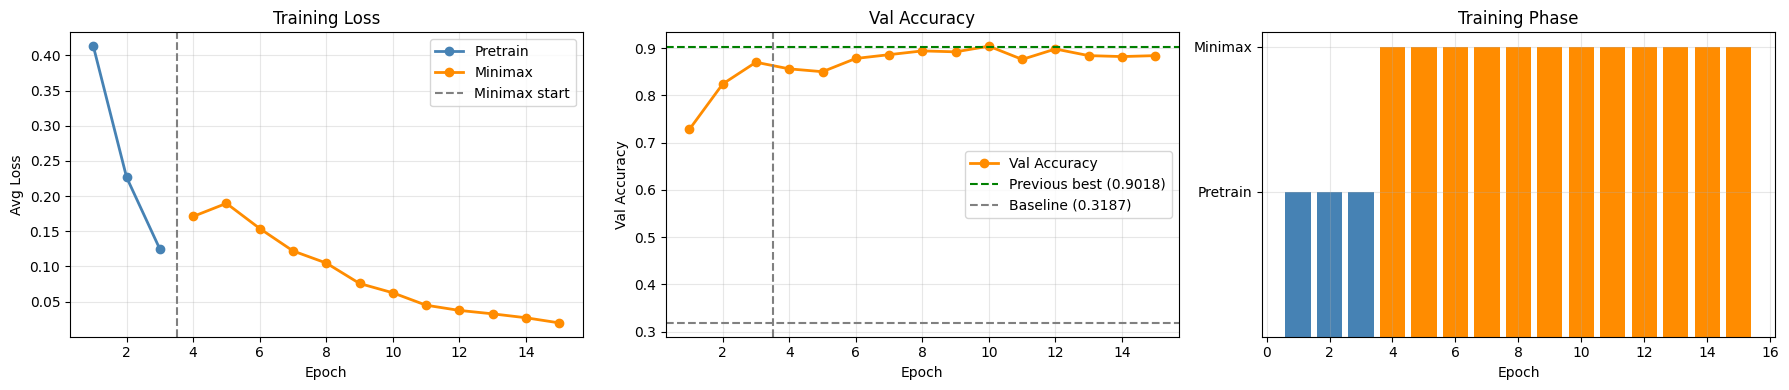


── Summary ──────────────────────────────────────────────
Epoch    Phase        Val Accuracy
-----------------------------------
1        pretrain     0.7280
2        pretrain     0.8240
3        pretrain     0.8700
4        minimax      0.8560
5        minimax      0.8500
6        minimax      0.8780
7        minimax      0.8860
8        minimax      0.8940
9        minimax      0.8920
10       minimax      0.9040
11       minimax      0.8760
12       minimax      0.8980
13       minimax      0.8840
14       minimax      0.8820
15       minimax      0.8840

Best val accuracy: 0.9040 at epoch 10
Previous best leaderboard: 0.9018


In [10]:
# ═══════════════════════════════════════════════════════════════
# Cell 9b — Minimax Training (resumable)
# ═══════════════════════════════════════════════════════════════

# ── Config ────────────────────────────────────────────────────
MINIMAX_EPOCHS       = 12
BATCH_SIZE           = 4
GRAD_ACCUM           = 4
LEARNER_LR           = 2e-4
AUX_LR               = 1e-3
VOCAB_SIZE           = 10000
C                    = 1.0

# ── Resume config ─────────────────────────────────────────────
# Set RESUME_MINIMAX_EPOCH = 0 to start minimax fresh from pretrain
# Set RESUME_MINIMAX_EPOCH = N to resume from minimax epoch N
RESUME_MINIMAX_EPOCH  = 0
PRETRAIN_EPOCHS_DONE  = 3  # how many pretrain epochs completed

# ── Load correct checkpoint ───────────────────────────────────
import gc
from peft import PeftModel
from transformers import AutoModelForVision2Seq

try:
    del learner
    gc.collect()
    torch.cuda.empty_cache()
except:
    pass

if RESUME_MINIMAX_EPOCH > 0:
    ckpt_path = LOG_DIR / f"minimax_epoch{RESUME_MINIMAX_EPOCH}_{run_id}"
    print(f"Resuming from minimax epoch {RESUME_MINIMAX_EPOCH}: {ckpt_path}")
else:
    ckpt_path = LOG_DIR / f"minimax_pretrain_epoch{PRETRAIN_EPOCHS_DONE}_{run_id}"
    print(f"Starting minimax from pretrain epoch {PRETRAIN_EPOCHS_DONE}: {ckpt_path}")

base_mm = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
)
base_mm.config.use_cache = False
learner = PeftModel.from_pretrained(base_mm, ckpt_path, is_trainable=True)
learner.print_trainable_parameters()

# ── Load auxiliary state if resuming ─────────────────────────
aux_model = AuxiliaryMLP(vocab_size=VOCAB_SIZE, embed_dim=64, hidden_dim=128)
if RESUME_MINIMAX_EPOCH > 0:
    aux_path = LOG_DIR / f"auxiliary_epoch{RESUME_MINIMAX_EPOCH}_{run_id}.pt"
    aux_model.load_state_dict(torch.load(aux_path, map_location="cpu"))
    print(f"Loaded auxiliary from: {aux_path}")
else:
    print("Starting with fresh auxiliary model.")

# ── Load existing log if resuming ────────────────────────────
log_path = LOG_DIR / f"minimax_log_{run_id}.json"
if log_path.exists():
    with open(log_path) as f:
        log = json.load(f)
    print(f"Loaded existing log with {len(log['val_accuracy_per_epoch'])} epochs recorded.")
else:
    log = {
        "run_id":                  run_id,
        "pretrain_loss_per_epoch": [],
        "minimax_loss_per_epoch":  [],
        "val_accuracy_per_epoch":  [],
        "phase":                   [],
        "previous_best":           0.9018,
    }
    print("Starting fresh log.")

# ── Optimizers ────────────────────────────────────────────────
learner_optimizer = PagedAdamW8bit(learner.parameters(), lr=LEARNER_LR, weight_decay=0.01)
aux_optimizer     = torch.optim.Adam(aux_model.parameters(), lr=AUX_LR,
                                      betas=(0.9, 0.999), eps=1e-8)

epochs_remaining  = MINIMAX_EPOCHS - RESUME_MINIMAX_EPOCH
total_steps       = (len(train_loader) // GRAD_ACCUM) * epochs_remaining
warmup_steps      = max(1, int(total_steps * 0.03))
minimax_scheduler = get_cosine_schedule_with_warmup(
    learner_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"\nMinimax epochs remaining: {epochs_remaining}")
ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# ═══════════════════════════════════════════════════════════════
# Minimax Training Loop
# ═══════════════════════════════════════════════════════════════
global_step = 0
learner.train()

for epoch in range(epochs_remaining):
    actual_epoch = RESUME_MINIMAX_EPOCH + epoch + 1
    total_loss   = 0
    learner_optimizer.zero_grad()
    aux_optimizer.zero_grad()

    for step, (inputs, labels, questions) in enumerate(
        tqdm(train_loader, desc=f"Minimax Epoch {actual_epoch}")
    ):
        # ── Auxiliary weights ──────────────────────────────────
        aux_feats   = build_aux_features(questions, vocab_size=VOCAB_SIZE)
        raw_weights = aux_model(aux_feats).detach()
        norm_weights = raw_weights / (raw_weights.mean() + 1e-8) + C
        norm_weights = norm_weights.to(learner.device)

        # ── Learner forward pass ───────────────────────────────
        inputs_gpu = {k: v.to(learner.device) if torch.is_tensor(v) else v
                      for k, v in inputs.items()}
        outputs    = learner(**inputs_gpu)

        logits       = outputs.logits
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = inputs_gpu["labels"][:, 1:].contiguous()

        per_token_loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            reduction="none",
            ignore_index=-100,
        ).view(shift_labels.size())

        mask            = (shift_labels != -100).float()
        per_sample_loss = (per_token_loss * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)

        # Learner minimizes weighted loss
        weighted_loss = (norm_weights * per_sample_loss).sum() / (GRAD_ACCUM * len(norm_weights))
        weighted_loss.backward()
        total_loss += per_sample_loss.mean().item()

        del outputs, logits, shift_logits, per_token_loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM == 0:
            # Update learner
            torch.nn.utils.clip_grad_norm_(learner.parameters(), 1.0)
            learner_optimizer.step()
            minimax_scheduler.step()
            learner_optimizer.zero_grad()

            # ── Update auxiliary ───────────────────────────────
            learner.eval()
            with torch.no_grad():
                outputs2        = learner(**inputs_gpu)
                logits2         = outputs2.logits
                shift_logits2   = logits2[:, :-1, :].contiguous()
                shift_labels2   = inputs_gpu["labels"][:, 1:].contiguous()
                per_token_loss2 = F.cross_entropy(
                    shift_logits2.view(-1, shift_logits2.size(-1)),
                    shift_labels2.view(-1),
                    reduction="none",
                    ignore_index=-100,
                ).view(shift_labels2.size())
                mask2            = (shift_labels2 != -100).float()
                per_sample_loss2 = (per_token_loss2 * mask2).sum(dim=1) / (mask2.sum(dim=1) + 1e-8)
            learner.train()

            aux_feats2   = build_aux_features(questions, vocab_size=VOCAB_SIZE)
            raw_weights2 = aux_model(aux_feats2)
            norm_w2      = raw_weights2 / (raw_weights2.mean() + 1e-8) + C
            aux_loss     = -(norm_w2 * per_sample_loss2.detach().cpu()).sum()
            aux_loss.backward()
            torch.nn.utils.clip_grad_norm_(aux_model.parameters(), 1.0)
            aux_optimizer.step()
            aux_optimizer.zero_grad()

            del outputs2, logits2, shift_logits2, per_token_loss2
            torch.cuda.empty_cache()
            global_step += 1

    avg_loss = total_loss / len(train_loader)
    log["minimax_loss_per_epoch"].append(avg_loss)
    log["phase"].append("minimax")
    print(f"Minimax Epoch {actual_epoch} | avg loss: {avg_loss:.4f}")

    # Val eval
    val_acc = evaluate(learner, val_df, DATA_DIR, n_samples=500, seed=epoch)
    log["val_accuracy_per_epoch"].append(val_acc)
    print(f"Minimax Epoch {actual_epoch} | val accuracy: {val_acc:.4f}")
    learner.train()

    # Save
    ckpt_path = LOG_DIR / f"minimax_epoch{actual_epoch}_{run_id}"
    learner.save_pretrained(ckpt_path)
    torch.save(aux_model.state_dict(),
               LOG_DIR / f"auxiliary_epoch{actual_epoch}_{run_id}.pt")
    with open(LOG_DIR / f"minimax_log_{run_id}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Saved: {ckpt_path}")

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f"RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM: {vram:.2f} GB")

# ── Final summary ─────────────────────────────────────────────
plot_training(log)
with open(LOG_DIR / f"minimax_log_{run_id}.json", "w") as f:
    json.dump(log, f, indent=2)

print(f"\n── Summary ──────────────────────────────────────────────")
print(f"{'Epoch':<8} {'Phase':<12} {'Val Accuracy'}")
print("-" * 35)
all_phases = log["phase"]
all_accs   = log["val_accuracy_per_epoch"]
all_losses = log["pretrain_loss_per_epoch"] + log["minimax_loss_per_epoch"]
for i, (phase, acc) in enumerate(zip(all_phases, all_accs)):
    print(f"{i+1:<8} {phase:<12} {acc:.4f}")

best_acc   = max(all_accs)
best_epoch = all_accs.index(best_acc) + 1
print(f"\nBest val accuracy: {best_acc:.4f} at epoch {best_epoch}")
print(f"Previous best leaderboard: 0.9018")

In [11]:
# ═══════════════════════════════════════════════════════════════
# Cell 10 — Generate Submissions for Selected Epochs
# ═══════════════════════════════════════════════════════════════
from peft import PeftModel
from transformers import AutoModelForVision2Seq

# ── Specify which epochs to generate submissions for ──────────
# Mix pretrain and minimax epochs as needed
SELECTED_EPOCHS = [
    {"phase": "minimax", "epoch": 5},
    {"phase": "minimax",  "epoch": 6},
    {"phase": "minimax",  "epoch": 7},
    {"phase": "minimax",  "epoch": 9},
    {"phase": "minimax",  "epoch": 11},
    {"phase": "minimax",  "epoch": 12},
]

for cfg in SELECTED_EPOCHS:
    phase = cfg["phase"]
    epoch = cfg["epoch"]

    if phase == "pretrain":
        ckpt_path = LOG_DIR / f"minimax_pretrain_epoch{epoch}_{run_id}"
    else:
        ckpt_path = LOG_DIR / f"minimax_epoch{epoch}_{run_id}"

    print(f"\n{'='*60}")
    print(f"Generating: {phase} epoch {epoch}")
    print(f"Checkpoint: {ckpt_path}")
    print(f"{'='*60}")

    if not ckpt_path.exists():
        print(f"WARNING: Checkpoint not found — skipping.")
        continue

    base_inf = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="cuda:0",
        low_cpu_mem_usage=True,
    )
    base_inf.config.use_cache = False
    infer_model = PeftModel.from_pretrained(base_inf, ckpt_path)
    infer_model.eval()

    test_results = []
    for idx in tqdm(range(len(test_df)), desc=f"{phase} ep{epoch} inference"):
        row    = test_df.iloc[idx]
        image  = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
        pred   = score_choices_nli(infer_model, processor, image, row, row["choices"])
        test_results.append({"id": row["id"], "answer": pred})

    submission_df = pd.DataFrame(test_results)
    sub_name      = f"submission_minimax_{phase}_epoch{epoch}_{run_id}.csv"
    submission_df.to_csv(sub_name, index=False)
    print(f"Saved: {sub_name} | Shape: {submission_df.shape}")

    del infer_model, base_inf
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll submissions generated.")


Generating: minimax epoch 5
Checkpoint: logs/minimax_epoch5_20260505_094905


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


minimax ep5 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved: submission_minimax_minimax_epoch5_20260505_094905.csv | Shape: (1008, 2)

Generating: minimax epoch 6
Checkpoint: logs/minimax_epoch6_20260505_094905


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

minimax ep11 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved: submission_minimax_minimax_epoch11_20260505_094905.csv | Shape: (1008, 2)

Generating: minimax epoch 12
Checkpoint: logs/minimax_epoch12_20260505_094905


/home/rohan/pixels/venv/lib/python3.12/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/home/rohan/pixels/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


minimax ep12 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved: submission_minimax_minimax_epoch12_20260505_094905.csv | Shape: (1008, 2)

All submissions generated.
